In [2]:

import time
import numpy as np
from numpy import linalg as LA

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 18})

# Task 1 - A pot with a handle

## Solve the ODE analytically
The general analytic solution for solving the heat transfer from finned surfaces is given by:

$$
\theta(x) = C_1 \cosh m(L-x) + C_2 \sinh m(L-x)
$$

In order to find the constants $C_1$ and $C_2$, apply the two boundary conditions.

### Boundary condition 1

Consider the value of  $\theta$ at the start of the handle:  $\quad \theta (0) = T_0 - T_{\infty} = \theta_0$

$$
\theta(0) = C_1 \cosh(mL) + C_2 \sinh(mL) = \theta_0
$$

### Boundary condition 2

Assuming that the end of the fin is isolated then: $\quad \theta '(L) =0 $

$$
\theta ' (x) = -mC_1 \sinh m(L-x) -mC_2 \cosh m(L-x)
$$

Setting $x=L$ gives:

$$
\theta '(L) = -mC_1 \sinh(0) -mC_2 \cosh(0) = -mC_2=0 \to C_2 =0
$$

Substituting this result into the first boundary condition gives:

$$
C_1 \cosh{mL} = \theta_0 \quad \to \quad C_1 = \frac{\theta_0}{\cosh{mL}}
$$

Hence:

$$
\boxed{\theta(x) = \theta_0 \, \frac{\cosh[m(L - x)]}{\cosh(mL)}}
$$

and the actual temperature varies as a function of x according to:

$$
\boxed{T(x) = T_{\infty} +(T_0 - T_{\infty}) \, \frac{\cosh[m(L-x)]}{cosh(mL)}}
$$





## Plug in physical data



| Symbol | Meaning | Value |
|:-------:|:---------:|:------:|
| $L$ | length of handle | $0.20~\text{m}$ |
| $w$ | width | $0.03~\text{m}$ |
| $t$ | thickness | $0.005~\text{m}$ (½ cm) |
| $P$ | perimeter | $2(w+t)=0.07~\text{m}$ |
| $A$ | cross-section area | $w\,t = 1.5\times10^{-4}~\text{m}^2$ |
| $h$ | convection coefficient | $5~\text{W\,m}^{-2}\,{}^{\circ}\text{C}^{-1}$ |
| $k$ | conductivity (Al) | $237~\text{W\,m}^{-1}\,{}^{\circ}\text{C}^{-1}$ |
| $T_0$ | base temperature | $100^{\circ}\text{C}$ |
| $T_\infty$ | ambient temperature | $25^{\circ}\text{C}$ |

Compute $m$:

$$
m = \sqrt{\frac{Ph}{kA}} = \sqrt{\frac{(0.07)\cdot(5)}{(237)\cdot(1.5 x 10^{-4})}} \approx 3.138
$$

Consider the temperature at the insulated end $x=L$ :

$$
T(L) \approx 25 + (100-25) \, \frac{1}{\cosh(3.138 \cdot 0.20)} = 87.319 
$$

So the end of the aluminium pan is extremenly hot and **not safe to touch**


In [3]:
x = 25 +(100-25)*1/(np.cosh(3.138*0.20))
print(f"Temperature at the end of the handle is {x:.2f} degrees")

Temperature at the end of the handle is 87.32 degrees


## Finite difference approximation

Define the problem parameters and functions for the analytical solutions.

In [4]:
# ---- Parameters ---- 
L = 0.20                 # Length of the domain
w, t = 0.03, 0.005       # width and thickness of handle
P, A = 2*(w+t), w*t      # Perimeter and cross-sectional area
h_conv = 5.0             # Convective heat transfer coefficient
k = 237.0                # Thermal conductivity of Aluminium
T0, T_inf= 100.0, 25.0         # Boundary temperatures (deg C)

theta0 = T0 - T_inf
m = np.sqrt(h_conv * P / (k * A))

def theta_exact(x, m=m, L=L, theta0=theta0):
    return theta0 * np.cosh(m*(L - x))/np.cosh(m*L)

def T_exact(x):
    return T_inf + theta_exact(x)




The following cell builds the finite-difference system for solving the boundary value problem:

$$
\theta ''(x) - m^2 \theta(x) = 0, \quad \quad \quad x \in [0,L]
$$

with mixed boundary conditions

$$
\theta (0) = \theta_0, \quad \quad \quad \theta ' (L) = 0.
$$

### Ghost Point Method

At the right boundary, the Neumann condition $\theta ' (L) = 0$ is approximated using a **ghost point** outside the domain:

$$
\frac{\theta_{N+1} - \theta_{N-1}}{2\Delta x} = 0 \quad \Rightarrow \quad \theta_{N+1} = \theta_{N-1}
$$

Substituting this into the finite-difference form of the differential equation at $i=N$:

$$
\frac{\theta_{N+1} - 2\theta_N + \theta_{N-1}}{\Delta x^2} - m^2\theta_N = 0,
$$

gives 

$$
\frac{2(\theta_{N-1} - \theta_N)}{\Delta x^2} -  m^2\theta_N = 0
$$

The system now includes $N+1$ gridpoints 

In [5]:
def build_system_ghost_N(N, m, L, theta0):
    dx = L / N
    x  = np.linspace(0, L, N + 1)   

    A = np.zeros((N+1, N+1))
    b = np.zeros(N+1)

    # Dirichlet at x=0
    A[0,0] = 1.0
    b[0]   = theta0

    lam = (m*dx)**2
    # interior points 
    for i in range(1, N):
        A[i, i-1] = 1.0
        A[i, i]   = -(2.0 + lam)
        A[i, i+1] = 1.0

    # ghost-point Neumann at i = N:
    A[N, N-1] =  2.0/(dx*dx)
    A[N, N]   = -2.0/(dx*dx) - m**2
    b[N]      =  0.0

    return x, dx, A, b

Define functions to extract the temperature from $\theta$ and solve the finite difference linear system

In [6]:
from numpy.linalg import solve as LA_solve
def T_from_theta(theta):
    return T_inf + theta

def solve_theta(N, m, L, theta0):
    x, dx, A, b = build_system_ghost_N(N, m, L, theta0)
    theta = LA_solve(A, b)
    return x, theta

### Compare numeric result with analytical solution

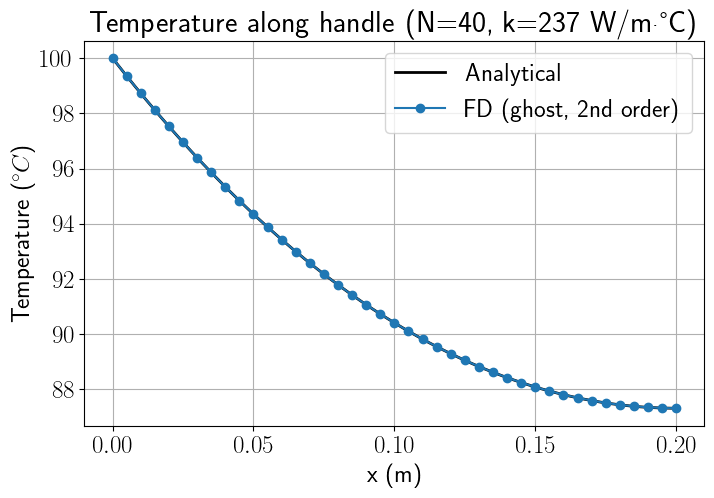

In [70]:
N = 40
x, theta_fd = solve_theta(N, m, L, theta0)
T_fd = T_inf + theta_fd



x_ref = np.linspace(0, L, 400)
T_ref = T_exact(x_ref)

plt.figure(figsize=(8,5))
plt.plot(x_ref, T_ref, 'k-', lw=2, label='Analytical')
plt.plot(x, T_fd, 'o-', label='FD (ghost, 2nd order)')
plt.xlabel('x (m)'); plt.ylabel(r"Temperature ($^{\circ}C$)")
plt.title(f"Temperature along handle (N={N}, k={k:.0f} W/m·°C)")
plt.grid(); plt.legend(); plt.show()

**Mesh Refinement and Convergence Check**

To ensure the finite-difference solution is properly resolved, I performed a mesh-refinement study. The idea is to solve the boundary-value problem on a sequence of grids with increasing resolution $(N, 2N, 4N, \dots)$, and compare successive solutions.

After computing the solution on a fine mesh, the previous (coarser) solution is interpolated onto the finer grid so that the two can be compared directly. I refined the mesh until the maximum difference between successive solutions fell below $10^{-6}$. At this point, further refinement produces no visible improvement, indicating the solution has numerically converged.

In [ ]:
def refinement_test(m, L, theta0, tol=1e-6):
    """
    Refines the grid until successive finite-difference solutions
    differ by less than the tolerance in the infinity norm.
    Returns the list of N values and corresponding solutions.
    """
    Ns = [10]        # start with a small grid
    solutions = []

    # Compute first solution
    x_old, theta_old = solve_theta(Ns[-1], m, L, theta0)
    solutions.append((x_old, theta_old))

    # Refinement loop
    while True:
        N_new = 2 * Ns[-1]          
        Ns.append(N_new)

        x_new, theta_new = solve_theta(N_new, m, L, theta0)

        # interpolate coarse solution onto fine grid
        theta_old_interp = np.interp(x_new, x_old, theta_old)

        # compute difference
        diff = np.max(np.abs(theta_new - theta_old_interp))

        print(f"N={N_new},  max difference = {diff:.3e}")

        solutions.append((x_new, theta_new))

        # stopping criterion
        if diff < tol:
            break

        # update for next loop
        x_old, theta_old = x_new, theta_new

    return Ns, solutions

In [67]:
Ns, solutions =refinement_test(m, L, theta0)


N=20,  max difference = 3.656e-02
N=40,  max difference = 9.185e-03
N=80,  max difference = 2.302e-03
N=160,  max difference = 5.762e-04
N=320,  max difference = 1.441e-04
N=640,  max difference = 3.604e-05
N=1280,  max difference = 9.012e-06
N=2560,  max difference = 2.253e-06
N=5120,  max difference = 5.633e-07


### Behaviour as $\Delta x$ is refined

- With very coarse grids (e.g. N=3), the numerical solutions reproduces the overall shape of $\theta (x)$, but the curvature is noticeable under resolved.
- As $N$ increases and $\Delta x$ becomes smaller, the second derivative stencil becomes a more accurate representation of the true second derivative.
- I refined the mesh until successive solutions changed only by $\approx 10^{-6}$, which indicated the solution had numerically converged.

In [56]:
from numpy.linalg import norm

# exact theta on grid
theta_ex = theta_exact(x)         
e = theta_fd - theta_ex

err_Linf = norm(e, np.inf)
err_L2_rms = norm(e) / np.sqrt(len(e))

print(f"L_inf error = {err_Linf:.3e}")
print(f"L2 (RMS)    = {err_L2_rms:.3e}")

L_inf error = 2.231e-04
L2 (RMS)    = 1.644e-04


Empirical order (L_inf) ~ 2.00
Empirical order (L2 RMS)~ 2.00


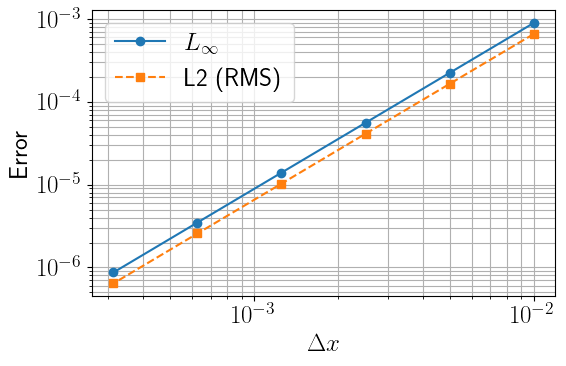

In [ ]:
from numpy.linalg import norm

def fd_errors_vs_N(Ns, builder="ghost"):
    dxs, Einf, E2rms = [], [], []
    for N in Ns:
        xN, thetaN = solve_theta(N, m, L, theta0) if builder=="ghost" else solve_theta(N, m, L, theta0)
        e = thetaN - theta_exact(xN)
        dxs.append(L/N)
        Einf.append(norm(e, np.inf))
        E2rms.append(norm(e) / np.sqrt(len(e)))
    return np.array(dxs), np.array(Einf), np.array(E2rms)

def slope(x, y, kslice=slice(1,5)):  # fit on a clean middle range
    X, Y = np.log(x)[kslice], np.log(y)[kslice]
    return np.polyfit(X, Y, 1)[0]

Ns = [20*2**k for k in range(6)]        # 20, 40, 80, ...
dx, Einf, E2 = fd_errors_vs_N(Ns, builder="ghost")

print(f"Empirical order (L_inf) ~ {slope(dx, Einf):.2f}")
print(f"Empirical order (L2 RMS)~ {slope(dx, E2):.2f}")

plt.figure(figsize=(6,4))
plt.loglog(dx, Einf, 'o-', label=r'$L_\infty$')
plt.loglog(dx, E2,   's--', label='L2 (RMS)')
plt.xlabel(r'$\Delta x$'); plt.ylabel('Error')
plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

### Error Analysis and Convergence Study

To assess the accuracy of the finite difference (FD) scheme, the numerical solution was compared to the analytical temperature distribution

$$
\theta(x) = \theta_0 \, \frac{\cosh[m(L-x)]}{\cosh(mL)},
$$

using both the $L_{\infty}$ (maximum) and $L_2$ (RMS) error norms:

$$
L_\infty = \max_i \, |\theta_i - \theta_{\text{exact}}(x_i)|, 
\qquad
L_2 = \frac{\sqrt{\sum_i (\theta_i - \theta_{\text{exact}}(x_i))^2}}{\sqrt{N+1}}.
$$

The grid spacing $\Delta x = L/N$ was halved successively to study the rate at which 
the error decreases.



| Norm | Empirical Order | Expected Order | Comment |
|:------:|:----------------:|:----------------:|:-----------|
| $L_\infty$ | $\approx 2.00$ | 2 | Matches theoretical second-order accuracy. |
| $L_2$ (RMS) | $\approx 2.00$ | 2 | Confirms overall quadratic convergence. |

The convergence plot below shows straight lines on a log–log scale with slope $\approx 2$ for both norms, demonstrating that the **ghost-point Neumann scheme** maintains **second-order global accuracy**, consistent with the central difference approximation used for $\theta''(x)$.


### Conclusion 
The finite difference model reproduces the analytic solution with 
second-order accuracy in both maximum and RMS error norms, confirming 
the theoretical prediction.

### Stainless Steel handle

Stainless steel: m = 12.472 1/m
T_end (analytic) = 37.30 °C
T_end (FD, N=100) = 37.30 °C


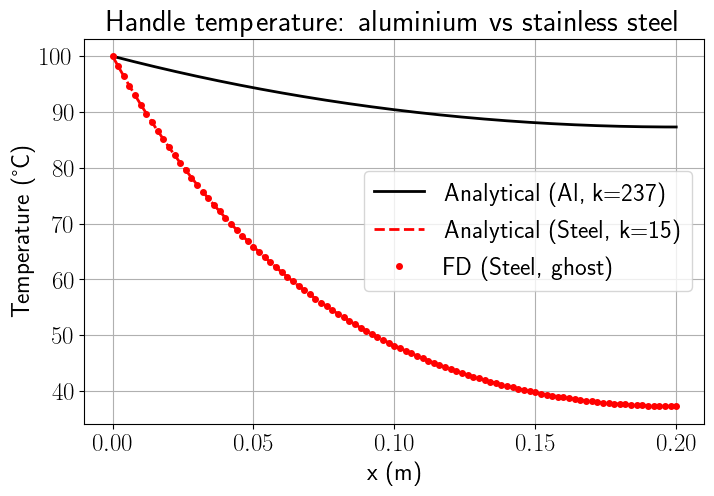

In [10]:
# switch material to stainless steel
k_ss = 15.0
m_ss = np.sqrt(P*h_conv/(k_ss*A))

# analytic profile
x_ref = np.linspace(0, L, 400)
T_ref_ss = T_inf + theta0*np.cosh(m_ss*(L - x_ref))/np.cosh(m_ss*L)

# FD solution (same solver as before, ghost-point BC)
N = 100
x_ss, theta_fd_ss = solve_theta(N, m_ss, L, theta0)
T_fd_ss = T_inf + theta_fd_ss

print(f"Stainless steel: m = {m_ss:.3f} 1/m")
print(f"T_end (analytic) = {T_ref_ss[-1]:.2f} °C")
print(f"T_end (FD, N={N}) = {T_fd_ss[-1]:.2f} °C")

# compare with aluminium (reuse previous m solution)
T_ref_al = T_exact(x_ref)              
plt.figure(figsize=(8,5))
plt.plot(x_ref, T_ref_al, 'k-',  lw=2, label='Analytical (Al, k=237)')
plt.plot(x_ref, T_ref_ss, 'r--', lw=2, label='Analytical (Steel, k=15)')
plt.plot(x_ss,  T_fd_ss,  'ro',  ms=4, label='FD (Steel, ghost)')
plt.xlabel('x (m)'); plt.ylabel('Temperature (°C)')
plt.title('Handle temperature: aluminium vs stainless steel')
plt.grid(); plt.legend(); plt.show()

With stainless steel $(k=15)$, the fin parameter increases to $m \approx 12.5 m^{-1}$, resulting in a much steeper temperature decay. The insulated end temperature falls to $\approx 37 ^\circ C$, compared to $\approx 98.5 ^\circ C$ for aluminium and is therefore safe to touch.

# Task 2 - Numerical integration to solve integral equations

Approximate the following function:

$$
y(s) = h(s) + \int_0^1 K(s,t)g(y(t))dt,
$$

using a quadrature rule with nodes $t_k \in [0,1]$ and weights $\omega_k$ to approximate the integral, define

$$
G(s,\vec{y}) = \sum_{k=0}^N \omega_k K(s,t_k)g(y_k)
$$

where $y_k \approx y(t_k)$. This gives the discrete in t equation:

$$
y(s) = h(s) + G(s,\vec{y}).
$$

Now evaluate at $s=t_l$:

$$
\boxed{F_l(\vec{y}) = y_l - (h(t_l) + \sum_{k=0}^N \omega_k K(t_l,t_k)g(y_k)) = 0, \quad \quad l=0, \dots , N.}
$$

This is the vector system $\vec{F}(\vec{y}) = 0$ that will be solved using Newton's method.

In matrix form, with $K_{lk} = K(t_l,t_k), \quad W = diag(\omega_0, \dots , \omega_N)$ :

$$
\vec{F}(\vec{y}) = \vec{y} - \vec{h} - KWg(\vec{y})
$$



### Jacobian

Obtain the Jacobian by differentiating $F_l$ with respect to $y_j$:

$$
\frac{\partial{F_l}}{\partial{y_j}} = \delta_{lk} - \omega_j K(t_l,t_j)g'(y_j) \quad \quad l,j = 0, \dots , N.
$$

In matrix form, with $\, G' = diag(g'(y_0), \dots ,g'(y_N))$:

$$
\boxed{DF(\vec{y}) = I -KWG'}
$$


### Newton Step

Given $\vec{y}_{m}$,

$$
|DF(\vec{y}_{m})|\Delta \vec{y}_{m} = -\vec{F}(\vec{y}_{m}), \quad \quad \quad \vec{y}_{m+1} = \vec{y}_{m} + \Delta \vec{y}_{m}
$$

The step $\Delta \vec{y}_{m}$ can be solved using:

$$
\Delta \vec{y}_m = LinearSolve(\mathbf{J}(\vec{y_m}),\mathbf{F}(\vec{y_m}))

## Quadrature Options

In [11]:
def trapezoidal(N,a,b):
    # quadrature weights on [0,1]
    omega = np.array( [0.5/(N-1)] + (N-2)*[1/(N-1),] + [0.5/(N-1)] )
    assert np.isclose(sum(omega),1)
    return np.linspace(a,b,N), omega*(b-a)

def simpson(N,a,b):
    assert N%2 == 1 # Simpson's rule needs an even number of interval so odd number of points
    # quadrature weight on [0,1]
    omega = np.ones(N)
    for i in range(1,(N+1)//2):
        omega[2*i-1] = 4
    for i in range(1,(N+1)//2-1):
        omega[2*i] = 2
    omega *= 1/(N-1)/3
    assert np.isclose(sum(omega),1)
    return np.linspace(a,b,N), omega*(b-a)

def gauss(N,a,b):
    x_ref, w_ref = np.polynomial.legendre.leggauss(N)

    # map from [-1,1] to [a,b]
    x = 0.5*(b - a)*x_ref + 0.5*(a + b)
    omega = 0.5*(b - a)*w_ref
    return x, omega 

## Problem definitions

Define different problems for:

$$
\boxed{y(s) = h(s) + \int_0^1 K(s,t)g(y(t))dt}
$$


Choice: $K(s,t) = 3st, \, g(y) = y^3, \,$ pick $y_{true}(s) = e^s$

$$
\int_0^1 K(s,t)g(y_{true}(t))dt = 3s\int_0^1 te^{3t}dt = s(\frac{2e^3+1}{3})
$$

Hence,

$$
h(s) = \frac{1}{3}(3e^s - s(2e^3+1))
$$

In [12]:
class Problem1:
    a, b = 0.0, 1.0
    y0=4.0
    @staticmethod
    def K(s, t):
        return 3.0*s*t
    @staticmethod
    def g(y):
        return y**3
    @staticmethod
    def dg(y):
        return 3.0*y**2
    @staticmethod
    def h(s):
        return (1.0/3.0)*(3.0*np.exp(s) - 2.0*s*np.exp(3.0)-s)
    @staticmethod
    def y_exact(s): return np.exp(s)

### Linear simple integrals

Choice: $K(s,t) =s, \, g(y) =y$, pick $y_{true}(s) = \sin{\pi s}$

$$
\int_0^1 K(s,t)g(y_{true}(t))dt = s\int_0^1 \sin{\pi t}dt = s\cdot\frac{2}{\pi}
$$

Hence,

$$
h(s) = sin{(\pi s)} - \frac{2}{\pi} \cdot s
$$



In [13]:
class ProblemSin:
    a, b = 0.0, 1.0
    y0 = 0.0
    @staticmethod
    def K(s, t): return s+0*t
    @staticmethod
    def g(y):  return y
    @staticmethod
    def dg(y): return np.ones_like(y)
    @staticmethod
    def h(s):  return np.sin(np.pi*s) - 2/(np.pi)*s
    @staticmethod
    def y_exact(s): return np.sin(np.pi *s)

### Linear with mild $s$ dependence

Choice: $K(s,t) =st, \, g(y) =y, \,$ pick $\, y_{true}(s) = e^s$

$$
\int_0^1 ste^t dt = s \int_0^1 te^t dt = s[(t-1)e^t]_0^1 = s \cdot 1 = s
$$

Hence,

$$
h(s) = e^s -s
$$

In [14]:
class ProblemExpLinear:
    a, b = 0.0, 1.0
    y0 = 1.0
    @staticmethod
    def K(s, t): return s*t
    @staticmethod
    def g(y):  return y
    @staticmethod
    def dg(y): return np.ones(y.size)
    @staticmethod
    def h(s):  return np.exp(s) - s
    @staticmethod
    def y_exact(s): return np.exp(s)

### Non-linear closed-form

Choice: $K(s,t) =s, \, g(y) =y^3, \,$ pick $\, y_{true}(s) = s$

$$
\int_0^1 s(y_{true}(t))^3 dt = s \int_0^1 t^3 dt = s \cdot \frac{1}{4}
$$

Hence,

$$
h(s) = s - \frac{s}{4} = \frac{3}{4} s
$$

In [15]:
class ProblemNonlinear:
    a, b = 0.0, 1.0
    y0 = 0.5
    @staticmethod
    def K(s, t): return s + 0*t
    @staticmethod
    def g(y):  return y**3
    @staticmethod
    def dg(y): return 3*y**2
    @staticmethod
    def h(s):  return 0.75*s
    @staticmethod
    def y_exact(s): return s

## Build F, DF and Newton Solver

The cell below defines a set of helper functions used to assemble and solve **nonlinear Hammerstein integral equations** of the form

$$
y(s) = h(s) + \int_0^1 K(s,t)g(y(t)) dt.
$$

The goal is to discretise this equation using numerical quadrature and solve the resulting nonlinear system with **Newton's method**.

### Function Overview

- `K_matrix(t, problem)` 

Constructs the discretised kernel matrix $K_{l,k} = K(t_l,t_k)$ for a given set of quadrature nodes t.
This allows the integral operator to be written as a standard matrix-vector product:

$$
(K\omega g(y))_l \approx \sum_k K(t_l,t_k)\omega_k g(y_k)
$$

- `F_vec(y,t, w, Problem, Kmat=None)`

Defines the nonlinear residual vector

$$
F(y) = y -(h(t) + K(w \odot g(y)) )
$$

which should vanish at the solution. Where $\odot$ denotes elementwise multiplication.

If Kmat is precomputed, it is reused for efficiency.

- `DF_mat(y, t, w, Problem, Kmat=None)` 

Builds the Jacobian of the nonlinear system:

$$
J = I - K diag(w \odot g'(y)).
$$

This derivative is needed in Newton's method to compute the update.


### `SolveHammerstein()`

This is the meain Newton solver that:

- Generates quadrature nodes and weights.
- Builds the Kernel matrix once for reuse.
- Iteratively solves the linearised system 

$$
J(y_k)\delta y = -F(y_k), \quad \quad \quad y_{k+1} = y_k + \delta y
$$

until convergence.

The **default tolerance** is set to $10^{-10}$. This choice ensures the residual norm $ ||F(y)||$ is reduced to a level consistent with double-precision accuracy.

Since the discretisation and quadrature errors are typically much larger than $10^{-10}$, this tolerance guarantees that Newton's iteration converges to the solution without overspending iterations on numerical noise.

- `SolveHammerstein_count()`

A solver that also returns the number of Newton iterations used `nit`.

It is used for performance studies when testing how number of Newton iterations varies with N.

In [16]:
def K_matrix(t, Problem):
    # K_{l,k} = K(t_l, t_k)
    return Problem.K(t[:,None], t[None,:])

def F_vec(y, t, w, Problem, Kmat=None):
    if Kmat is None:
        Kmat = K_matrix(t, Problem)
    return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))

def DF_mat(y, t, w, Problem, Kmat=None):
    if Kmat is None:
        Kmat = K_matrix(t, Problem)
    gp = Problem.dg(y)
    return np.eye(len(t)) - Kmat * (w*gp)[None,:]

def SolveHammerstein(N, Problem, quadrature=trapezoidal, tol=1e-10, max_iter=50, verbose=False):
    t,w = quadrature(N, Problem.a, Problem.b)
    # Initial guess
    y = np.full(len(t), Problem.y0, dtype=float)
    # Precompute K matrix once for all iterations
    Kmat = K_matrix(t, Problem)

    for it in range(max_iter):
        Fv= F_vec(y, t, w, Problem, Kmat)
        nF = np.linalg.norm(Fv)
        if verbose:
            print(f"  it={it}, ||F||={nF:.3e}")
        if nF < tol:
            break
        J = DF_mat(y, t, w, Problem, Kmat)
        dy = np.linalg.solve(J, -Fv)
        y += dy
    return t, y

def solveHammerstein_count(N, Problem, quadrature, tol=1e-10, max_iter=50):
    # Generate quadrature nodes and weights
    t, w = quadrature(N, Problem.a, Problem.b)
    y = np.full(len(t), Problem.y0, float)

    # Precompute the kernel matrix once
    Kmat = K_matrix(t, Problem)

    # Newton iteration
    nit = 0
    for nit in range(1, max_iter + 1):
        Fv = F_vec(y, t, w, Problem, Kmat)
        if np.linalg.norm(Fv) < tol:
            break
        J = DF_mat(y, t, w, Problem, Kmat)
        dy = np.linalg.solve(J, -Fv)
        y += dy

    return t, y, nit

## Test on Problem with Exact Solution

Quick test to see the RMS error for a given quadrature and gridsize $N$.

In [41]:
quad = simpson
problem = Problem1

N = 115
t, y_num = SolveHammerstein(N, problem, quadrature=quad, tol = 1e-12, verbose=False)
y_exact = problem.y_exact(t)


err_L2 = np.sqrt(np.mean((y_num - y_exact)**2))
print(f"N={N}, quadrature={quad.__name__},  L2 error = {err_L2:.3e}")

N=115, quadrature=simpson,  L2 error = 4.514e-09


/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: divide by zero encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: overflow encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: invalid value encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))


The cell below measures how quickly the numerical error decreases as the number of quadrature points $N$ increases.

- `eoc_from_errors` computes the empirical order of convergence:

$$
p_i = \frac{log(e_i / e_{i-1})}{log(h_i/h_{i-1})}
$$

It compares successive errors to estimate how the error scales with grid refinement.

- For each quadrature rule (trapezoidal, simpson, gauss), the Hammerstein equation is solved with increasing N and the RMS error between the numerical and exact solutions is computed.

The number of Newton iterations is also stored.


The dictionary `results` stores all computed data for each quadrature method in a structured form.

Each key corresponds to a quadrature rule (trapezoidal, simpson, gauss). 

For each rule, the value is another dictionary containing: 

- `N` -> the list of grid sizes used
- `err` -> the array of RMS errors for each $N$
- `iters` -> the number of Newton iterations needed for convergence.


In [ ]:

def eoc_from_errors(N_list, errs):
    eoc = []
    for i in range(1, len(N_list)):
        num = np.log(errs[i]/errs[i-1])
        den = np.log((N_list[i-1]-1)/(N_list[i]-1))
        eoc.append(num/den)
    return np.array(eoc)

# Define the number of grid sizes to include in plot
N_points = 10

Ns = [(2**i) + 1 for i in range(1, N_points + 1)]  # 3,5,9,...,513 (odd -> OK for Simpson)

results = {}
for quad in (trapezoidal, simpson, gauss):
    errs, iters = [], []
    for N in Ns:
        t, y, nit = solveHammerstein_count(N, problem, quadrature=quad, tol=1e-12, max_iter=50)
        y_exact = problem.y_exact(t)
        # RMS error
        eN = np.sqrt(np.mean((y - y_exact)**2))   
        errs.append(eN)
        iters.append(nit)
    results[quad.__name__] = dict(N=Ns, err=np.array(errs), iters=np.array(iters))

# Compute EOC arrays
eoc_trap = eoc_from_errors(results['trapezoidal']['N'], results['trapezoidal']['err'])
eoc_simp = eoc_from_errors(results['simpson']['N'],     results['simpson']['err'])
print("EOC (trapezoidal):", np.round(eoc_trap, 3))
print("EOC (simpson):    ", np.round(eoc_simp, 3))

/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: divide by zero encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: overflow encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: invalid value encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))


EOC (trapezoidal): [1.786 1.957 2.    2.005 2.004 2.002 2.001 2.001 2.   ]
EOC (simpson):     [3.693 3.945 3.998 4.005 4.004 4.002 4.001 4.001 4.   ]


Empirical order (Trapezoidal) ~ 1.99
Empirical order (Simpson)~ 3.98
Trapezoidal EOC (in asymptotic regime): 2.0003465256516875
Simpson EOC (in asymptotic regime): 4.000348024459303


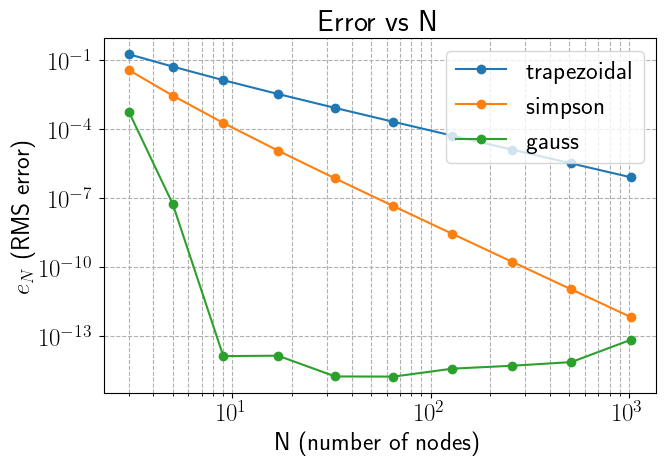

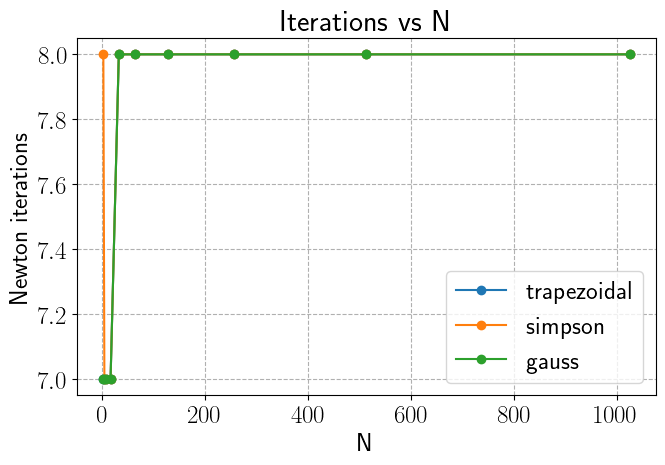

Machine precision (float64): 2.220e-16


In [ ]:
import matplotlib.pyplot as plt

print(f"Empirical order (Trapezoidal) ~ {slope(dx, results['trapezoidal']['err']):.2f}")
print(f"Empirical order (Simpson)~ {slope(dx, results['simpson']['err']):.2f}")
print(f"Trapezoidal EOC (in asymptotic regime): {eoc_trap[-1]}")
print(f"Simpson EOC (in asymptotic regime): {eoc_simp[-1]}")


# --- Error vs N ---
plt.figure(figsize=(7,5))
for name in ['trapezoidal', 'simpson', 'gauss']:
    plt.loglog(results[name]['N'], results[name]['err'], 'o-', label=name)
plt.xlabel('N (number of nodes)')
plt.ylabel(r'$e_N$ (RMS error)')
plt.title('Error vs N')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.tight_layout()
plt.show()

# --- Newton iterations vs N ---
plt.figure(figsize=(7,5))
for name in ['trapezoidal', 'simpson', 'gauss']:
    plt.plot(results[name]['N'], results[name]['iters'], 'o-', label=name)
plt.xlabel('N')
plt.ylabel('Newton iterations')
plt.title('Iterations vs N')
plt.grid(True, ls='--')
plt.legend()
plt.tight_layout()
plt.show()

# print machine precision
import sys
print(f"Machine precision (float64): {sys.float_info.epsilon:.3e}")

## Discussion of Results for Problem1

### Convergence behaviour

The first plot (Error vs N) shows the **RMS error** $e_N$ decreasing as the number of quadrature nodes N increases for all three integration rules:

- **Trapezoidal rule (blue)** decreases linearly on the log-log scale with slope $\approx -2$, confirming second-order convergence $e_n \propto h^2$. When $N$ roughly doubles (so h halves), the error decreases by a factor of $2^2 = 4$.
- **Simpson rule (orange)** decreases much more steeply, with slope $\approx -4$, consistent with its fourth-order accuracy $e_n \propto h^4$. Doubling N now reduces the error by about $2^4 =16$.
- **Gauss-Legendre (green)** achieves extremely rapid, almost exponential error decay. The error drops below $10^{-13}$ with fewer than $10$ nodes and then saturates at machine precision $(\approx 10^{-14} - 10^{-15})$. This happens because Gauss quadrature is exact for all polynomials up to degree $2N-1$ and the test function $e^s$ is analytic.

To see why this Gauss-Legendre quadrature is so efficient, consider the Taylor expansion of $e^s$:

$$
e^s = \sum_{k=0}^{\infty} \frac{s^n}{k!} = 1 + s + \frac{s^2}{3!} + \frac{s^3}{3!} + \frac{s^4}{4!} + \dots
$$

Gauss quadrature integrates all the polynomial terms up to degree $N-1$ exactly, so the only error comes from the remaining higher-order terms $O(s^{2N})$

Since the coefficients of these higher terms are factorially small $(\frac{1}{k!})$, the truncation error becomes extrememly small very quickly.

For analytic functions, the Taylor coefficients decay faster than any powers of $1/N$. Because Gauss quadrature integrates the lower-degree terms exactly, the remaining series tail shrinks roughly exponentially fast like $O(e^{cN})$ for some constant $c>0$. This is why in the Error vs N plot, the Gauss curve quickly falls to $\approx 10^{-13}$ with only a few points and then flattens at machine precision.



### Newton Iteration Count

The second plot (Iterations vs N) shows that the number of Newton iterations remains nearly constant $(\approx 7-8)$ for all $N$ and for all quadrature rules. This mean:

- The nonlinearity $g(y) = y^3$ is mild enough that Newton's method converges quadratically once close to the solution.
- Refining the quadrature (increasing $N$) only increases the system size and doesn't affect convergence speed.
- There is no significant difference between the quadratures in iteration count. All reach the tolerance in roughly the same number of steps.

### Summary

| Quadrature | Observed Order | Error Reduction when N Doubles | Newton Iterations | Remarks |
|-------------|----------------|--------------------------------|-------------------|----------|
| **Trapezoidal** | ≈ 1.99 | × 4 smaller | ~8 | 2nd-order convergence, slower but steady |
| **Simpson** | ≈ 3.98 | × 16 smaller | ~8 | 4th-order convergence, much higher accuracy |
| **Gauss** | exponential | Reaches machine precision | ~8 | Extremely rapid convergence for smooth functions |

### Conclusion

The numerical results match theoretical expectations. The trapezoidal and Simpson rules exhibit second- and fourth-order convergence, respectively, while Gauss quadrature achieves near machine-precision accuracy with very few nodes. The Newton solver requires roughly the same number of iterations regardless of quadrature rule or grid refinement, showing that convergence of the nonlinear system is robust and largely independent of $N$.

## Testing Additional Problem Classes

**ProblemNonlinear** (polynomial test)

Consider the nonlinear Hammerstein problem

$$
y(s) = h(s) + \int_0^1 K(s)(t)g(y(t))dt, \quad \quad \quad K(s,t) = s, \quad g(y) = y^3
$$

with the target solution $y_{exact}(s) = s$.

The integral part of the problem reduces to:

$$
s\cdot \int_0^1 t^3 dt
$$

which drastically improved the efficiency of Simpson quadrature.

Consider the error vs N graph for the three different quadrature schemes

/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: divide by zero encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: overflow encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_1095/1931648102.py:8: RuntimeWarning: invalid value encountered in matmul
  return y - (Problem.h(t) + Kmat @ (w * Problem.g(y)))


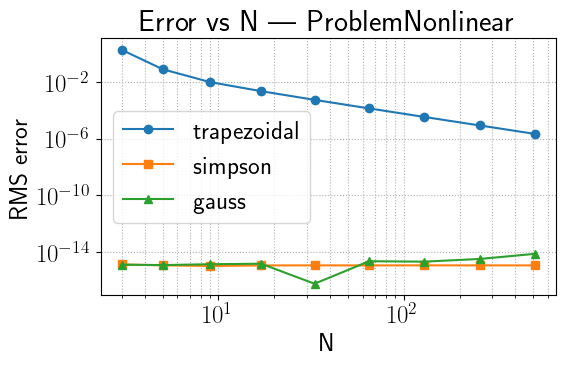

[1.28996259e-15 1.11576033e-15 9.99082925e-16 1.09609850e-15
 1.10612902e-15 1.10160379e-15 1.10957821e-15 1.10563750e-15
 1.09806302e-15]
Trapezoidal EOC in asymptotic region: 2.0008


In [ ]:
Problem = ProblemNonlinear

Ns = [(2**i) + 1 for i in range(1, 10)]

# --- Run experiments for selected quadratures ---
quads = (trapezoidal, simpson, gauss)
results = {}
for quad in quads:
    errs, iters = [], []
    for N in Ns:
        t, y, nit = solveHammerstein_count(N, Problem, quadrature=quad, tol=1e-12, max_iter=50)
        if hasattr(Problem, "y_exact"):
            y_exact = Problem.y_exact(t)
            eN = np.sqrt(np.mean((y - y_exact)**2))
        else:
            eN = np.nan
        errs.append(eN)
        iters.append(nit)
    results[quad.__name__] = dict(N=np.array(Ns), err=np.array(errs), iters=np.array(iters))

# --- Plot: Error vs N ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
for name, style in zip(results.keys(), ["o-","s-","^-"]):
    # Use loglog plot 
    plt.loglog(results[name]['N'], results[name]['err'], style, label=name)
plt.xlabel("N")
plt.ylabel("RMS error")
plt.title(f"Error vs N — {Problem.__name__}")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()

print(results['simpson']['err'])
eoc_trap = eoc_from_errors(results['trapezoidal']['N'], results['trapezoidal']['err'])
print(f"Trapezoidal EOC in asymptotic region: {eoc_trap[-1]:.4f}")

- **Simpson's rule** achieves machine precision $(\approx 10^-15)$ even for small $N$

This happens because Simpsons's rule is exact for integrals up to cubic order.

Simpson's rule corresponds to integrating exactly any function expressible as a cubic Legendre polynomial expansion over the interval $[0,1]$. Therefore, the quadrature introduces zero discretisation error for this problem.

- **Trapezoidal rule** shows empirical orders starting above $4$ for very coarse grids and gradually settling toward the theoretical value of $2$ as $N$ increases.

This behaviour occurs because the error is still influenced by higher-order terms when the mesh is coarse (i.e. pre-asymptotic regime), and because the integrand in this problem is extremely smooth (a cubic polynomial).

**Note**: To test on different problem classes change the variable `problem` in cell 36 and run cells 36-38

# Task 3 - Some Math

**Goal**: Show that 

$$
(a(x)u'(x))' = a(x+\frac{h}{2})\frac{u(x+h) - u(x)}{h^2} - a(x-\frac{h}{2})\frac{u(x)-u(x-h)}{h^2} + O(h^2)
$$

assuming $a, u$ are smooth.

**Solution**: 

Define $q(x) = a(x)u'(x)$ and hence we wnat to find an expression for $q'(x) = (a(x)u'(x))'$.



Approximate the derivative of q using the central differnce scheme with points $x -\frac{h}{2}, x, x+\frac{h}{2}$:

Start by Taylor expanding $q(x+\frac{h}{2})$ and $q(x-\frac{h}{2})$ about point $x$:

$$
\begin{align}
q(x+\frac{h}{2}) &= q(x) + \frac{h}{2}q'(x) + \frac{h^2}{4}\frac{1}{2}q''(x) + \frac{h^3}{8}\frac{1}{6} q'''(x) + \dots\\
q(x-\frac{h}{2}) &= q(x) - \frac{h}{2}q'(x) + \frac{h^2}{4}\frac{1}{2}q''(x) - \frac{h^3}{8}\frac{1}{6} q'''(x) + \dots
\end{align}
$$

Taking the difference of (1) and (2) and dividing by h gives the central difference approximation up to $O(h^2)$:

$$
\frac{q(x+\frac{h}{2}) - q(x-\frac{h}{2})}{h} = q'(x) + \frac{h^2}{24}q'''(x) + \dots = q'(x) + O(h^2)
$$

Now apply the centred difference scheme again for $u'(x \pm \frac{h}{2})$ in order to evaluate $q(x \pm \frac{h}{2})$


$$
\begin{align}
u'(x+\frac{h}{2}) \approx \frac{u(x+h) - u(x)}{h} + O(h^2) \\ 
u'(x-\frac{h}{2}) \approx \frac{u(x) - u(x-h)}{h} + O(h^2)
\end{align}
$$

Hence,

$$
\begin{align}
q(x+\frac{h}{2}) \approx a(x+\frac{h}{2})\frac{u(x+h) - u(x)}{h} + O(h^2) \\
q(x-\frac{h}{2}) \approx a(x-\frac{h}{2})\frac{u(x) - u(x-h)}{h} + O(h^2)
\end{align}
$$

Finally assemble the above results:

$$
\boxed{q'(x) = (a(x)u'(x))' = a(x+\frac{h}{2})\frac{u(x+h)-u(x)}{h^2} - a(x-\frac{h}{2})\frac{u(x)-u(x-\frac{h}{2})}{h^2} + O(h^2)}
$$

Both the outer central difference and each inner central difference have truncation error $O(h^2)$. Their combination still yeads a scheme whose leading truncation error is $O(h^2)$, provided $a,u$ are $C^3$ (or smoother) so the expansions are valid.

Define $q(x) 